Train shape: (7000, 12)
Test shape: (3000, 11)


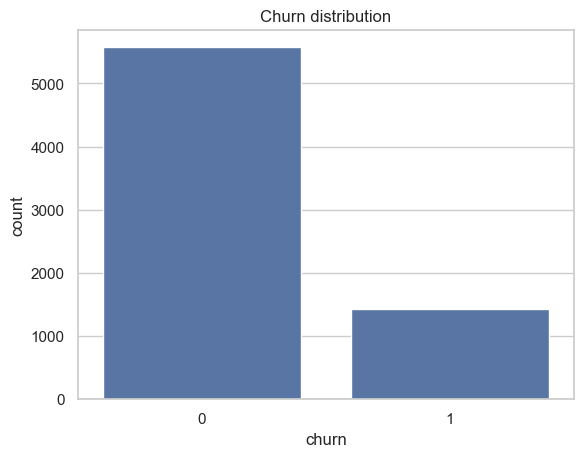

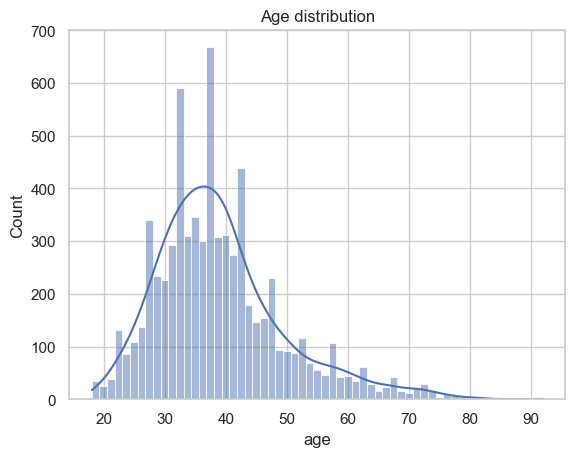

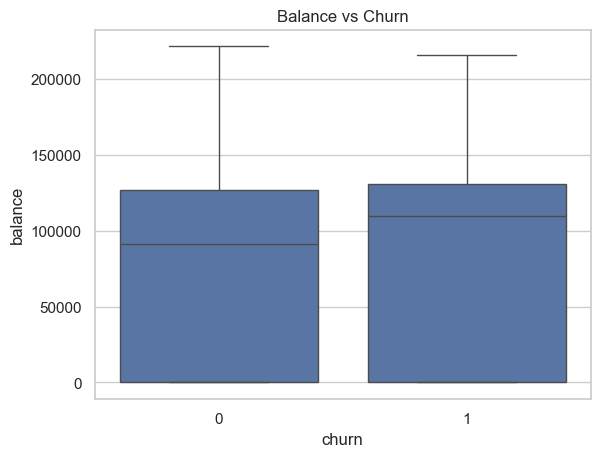

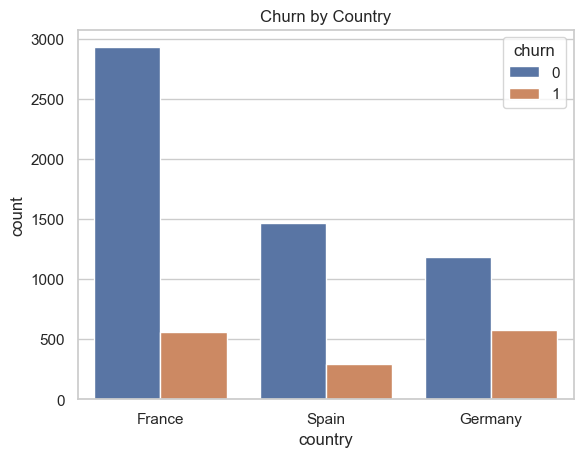

Validation Accuracy: 0.8007142857142857
Validation ROC-AUC: 0.7656769727008103
submission.csv saved ✅


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score



In [79]:
df = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", df.shape)
print("Test shape:", test.shape)


Train shape: (7000, 12)
Test shape: (3000, 11)


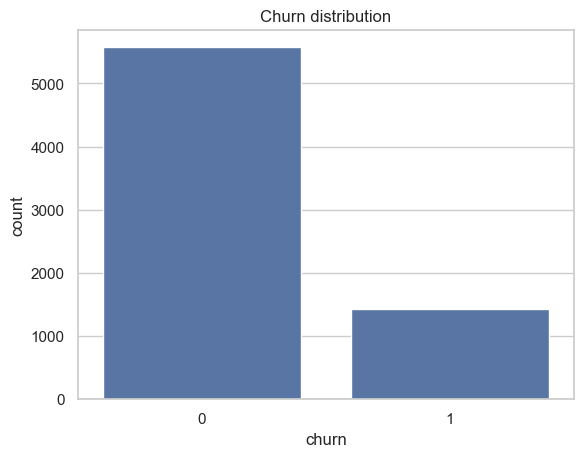

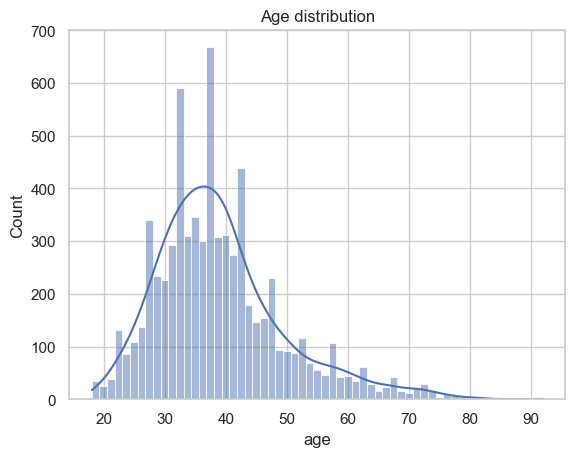

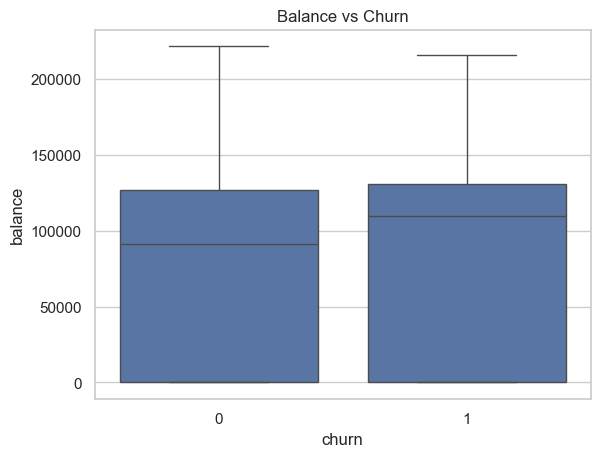

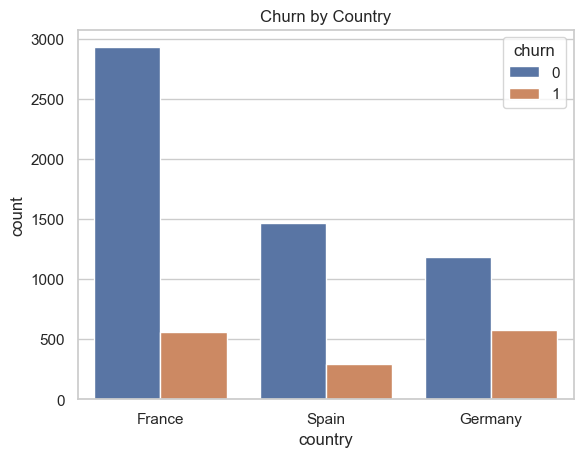

In [80]:
sns.countplot(x="churn", data=df)
plt.title("Churn distribution")
plt.show()

sns.histplot(df["age"], kde=True)
plt.title("Age distribution")
plt.show()

sns.boxplot(x="churn", y="balance", data=df)
plt.title("Balance vs Churn")
plt.show()

sns.countplot(x="country", hue="churn", data=df)
plt.title("Churn by Country")
plt.show()


In [81]:
X = df.drop(["churn", "customer_id"], axis=1)
y = df["churn"]

In [82]:
X = pd.get_dummies(X, columns=["country", "gender"], drop_first=True)

In [83]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [84]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)

X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=X.columns
)


In [85]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [86]:
y_pred = model.predict(X_val)                   # class labels
y_pred_proba = model.predict_proba(X_val)[:, 1] # probabilities

print("Validation Accuracy:", accuracy_score(y_val, y_pred))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_pred_proba))


Validation Accuracy: 0.8007142857142857
Validation ROC-AUC: 0.7656769727008103


In [88]:
X_full = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)
model.fit(X_full, y)

LogisticRegression(max_iter=1000)

In [89]:
id_col = [col for col in test.columns if "id" in col.lower()][0]
test_ids = test[id_col]
test = test.drop(id_col, axis=1)

In [90]:

test = pd.get_dummies(test, columns=["country", "gender"], drop_first=True)


test = test.reindex(columns=X.columns, fill_value=0)


test = pd.DataFrame(
    scaler.transform(test),
    columns=X.columns
)

In [91]:
test_pred_proba = model.predict_proba(test)[:, 1]


test_pred_binary = (test_pred_proba >= 0.5).astype(int)

In [92]:
submission = pd.DataFrame({
    "customer_id": test_ids,
    "churn": test_pred_binary
})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved ")

submission.csv saved 
